In [1]:
import os
import sys

# Path to project root (works both in .py and .ipynb)
def get_project_root(levels_up=2):
    try:
        here = os.path.dirname(__file__)
    except NameError:
        here = os.getcwd()
    return os.path.abspath(os.path.join(here, *([".."] * levels_up)))

root_dir = get_project_root(2)

# Add paper folder
paper_dir = os.path.join(root_dir, "paper")
sys.path.insert(0, paper_dir)

# Import PyGhostID package and 
import PyGhostID as gid

import utils_paper as fun
print(fun.__file__)
import models_paper as mod

# other imports
import numpy as np
from scipy.integrate import solve_ivp
import jax
import jax.numpy as jnp
from jax.nn import sigmoid
from jax import jacfwd

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pylab as pylab
from matplotlib.collections import LineCollection
import pickle

# No warnings
import warnings
warnings.filterwarnings("ignore")

pylab.rcParams.update(fun.get_rcparams())
plt.rcParams.update({'font.family':'Arial'})

inCm = 1/2.54 # convert inch to cm for plotting

saveFigs = False

w:\GitHub\GhostID\paper\utils_paper.py


Additional examples of long transients due to slow-fast dynamics

1 ghosts identified in Kuehn slow-fast toy model.


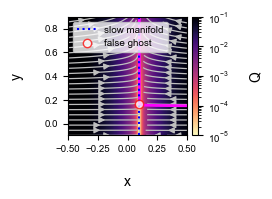

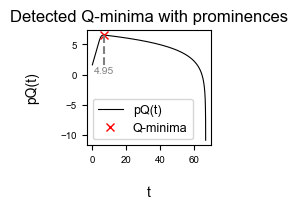

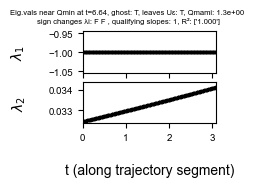

In [2]:
# Toy model for slow-fast systems (Kuehn 2015)
# set parameters
eps=0.1
parameters_kuehn =  eps

# simulate trajectories
dt = 0.01
timesteps = np.linspace(0,100,int(100/dt))

sol2 = solve_ivp(mod.Kuehn_toyModel, (0, 100), [0.5,0.15],
                    t_eval=timesteps, args=(parameters_kuehn,),method='RK45')

Trj2=sol2.y.T
ghostSeq2, ctrlPlots2 = gid.ghostID(mod.Kuehn_toyModel,parameters_kuehn,dt,Trj2,0.005,evLimit=0.05,peak_kwargs={"prominence":0,"width":100},ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":True}) #

if len(ghostSeq2)==0: 
      print("No ghosts in Kuehn slow-fast toy model identified.")
else:
      print(f"{len(ghostSeq2)} ghosts identified in Kuehn slow-fast toy model.")   

# plot phase space
xmin=-0.5;xmax=0.5
ymin=-.1;ymax=0.9

Ng=100
x_range=np.linspace(xmin,xmax,Ng)
y_range=np.linspace(ymin,ymax,Ng)
grid_ss = np.meshgrid(x_range, y_range)
Xg,Yg=grid_ss

Q, coords = gid.qOnGrid(mod.Kuehn_toyModel,parameters_kuehn,coords=[x_range,y_range], jit=True)

plt.figure(figsize=(4.25*inCm,6*inCm))
ax = plt.gca()

def flow_model(t,z): 
        return mod.Kuehn_toyModel(t,z,parameters_kuehn)
U,V=fun.vector_field(flow_model,(Xg, Yg),dim='2D') 

ax.streamplot(
    Xg, Yg,
    U,V,
    density=0.8,
    color=[0.75, 0.75, 0.75, 1],
    arrowsize=0.9,
    linewidth=0.9)

# plot trajectory
ax.plot(sol2.y[0],sol2.y[1],'-',color='magenta',lw=2)

# slow manifold
ax.plot(0*y_range+eps,y_range,':',color='blue',label='slow manifold')

# plot ghost locations
for ghost in ghostSeq2:
    ax.plot(ghost['position'][0],ghost['position'][1],'o',color='w',mec='r',label='false ghost',alpha=0.75)

# plot Q-value
vmin = 1e-5 # Define log scale range 
vmax = 0.1 # Avoid zero or negative values 
im = ax.imshow(Q.T, extent=(x_range.min(), x_range.max(), y_range.min(), y_range.max()), origin='lower', cmap='magma_r', norm=LogNorm(vmin=vmin, vmax=vmax)) 

# add colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax,label="Q")

#labels, limits, legend
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_xlim(xmin,xmax); 
ax.set_ylim(ymin,ymax);
ax.legend(fontsize=7)
if saveFigs: plt.savefig("SFig3_phaseSpace.svg")
plt.show()

# Plot control outputs from ghostID

fig, ax = ctrlPlots2[0]
fig.set_size_inches(4.5*inCm,5.5*inCm)
plt.figure(fig)
if saveFigs: plt.savefig("FalseGhost_pQ.svg")
plt.show()

# eigenvalues across trajectories
fig, axes = ctrlPlots2[1]
suptxt = fig._suptitle.get_text()
fig.suptitle(suptxt,fontsize=5.5)
fig.set_size_inches(5*inCm,3.75*inCm)
axes[0].set_xlim(0,3.1)
axes[1].set_xlim(0,3.1)
axes[0].set_ylabel('$\\lambda_1$')
axes[1].set_ylabel('$\\lambda_2$')
axes[1].set_xlabel('t (along trajectory segment)')
plt.figure(fig)
if saveFigs: plt.savefig("SFig3_evs.svg")
plt.show()
